In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Allow importing from src/
sys.path.append(os.path.abspath('../'))
from src.data_preprocessing import merge_ip_to_country

# Load raw datasets
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print(f"Fraud Dataset Shape: {fraud_df.shape}")
print(f"Missing Values:\n{fraud_df.isnull().sum()}")
print(f"Duplicate Rows: {fraud_df.duplicated().sum()}")

# Drop duplicates if any exist
fraud_df = fraud_df.drop_duplicates()

# Correct datetime types
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

Fraud Dataset Shape: (151112, 11)
Missing Values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
Duplicate Rows: 0


In [31]:
# Apply our modular optimized merge
fraud_enriched = merge_ip_to_country(fraud_df, ip_df)

# Check out top fraud-heavy countries
country_stats = fraud_enriched.groupby('country').agg(
    total_transactions=('class', 'count'),
    fraud_cases=('class', 'sum'),
    fraud_rate=('class', 'mean')
).sort_values(by='fraud_cases', ascending=False)

print("\nTop 10 Fraudulent Countries by Case Volume:")
print(country_stats.head(10))


Top 10 Fraudulent Countries by Case Volume:
                   total_transactions  fraud_cases  fraud_rate
country                                                       
United States                   58049         5551    0.095626
Unknown                         21966         1883    0.085723
China                           12038         1043    0.086642
Japan                            7306          715    0.097865
United Kingdom                   4490          477    0.106236
Korea Republic of                4162          380    0.091302
Canada                           2975          348    0.116975
France                           3161          300    0.094907
Brazil                           2961          270    0.091185
Germany                          3646          262    0.071860


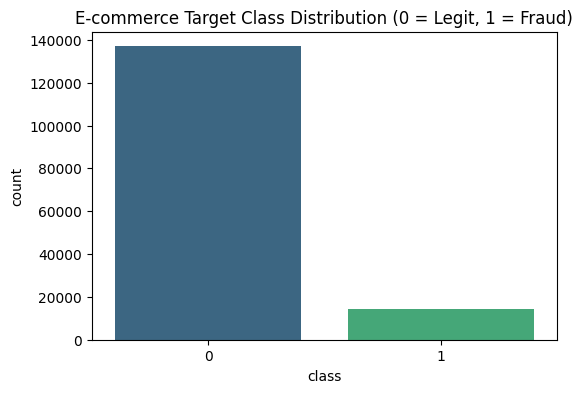

Legitimate: 90.64% | Fraudulent: 9.36%


In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=fraud_enriched, palette='viridis')
plt.title('E-commerce Target Class Distribution (0 = Legit, 1 = Fraud)')
plt.show()

imbalance_ratio = fraud_enriched['class'].value_counts(normalize=True) * 100
print(f"Legitimate: {imbalance_ratio[0]:.2f}% | Fraudulent: {imbalance_ratio[1]:.2f}%")

In [33]:
fraud_enriched.to_csv('../data/processed/fraud_data_enriched.csv', index=False)